In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from textblob import TextBlob
from wordcloud import WordCloud

In [ ]:
# NLTK for Stopwords (words like 'is', 'the', 'and' that don't add sentiment value)
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Magic command for Colab
%matplotlib inline

In [ ]:
class NLPSentimentPipeline:
    """
    Advanced NLP Pipeline for Text Preprocessing and Sentiment Analysis.
    Utilizes TextBlob for polarity scoring and WordCloud for text visualization.
    """

    def __init__(self, filepath: str):
        sns.set_theme(style="whitegrid")
        self.colors = ['#2ecc71', '#95a5a6', '#e74c3c'] # Green(Pos), Gray(Neu), Red(Neg)

        try:
            self.df = pd.read_csv(filepath)
            print(f"[OK] Dataset '{filepath}' loaded successfully with {self.df.shape[0]} rows.")

            # Identify the text column (Usually named 'Text' or 'text')
            text_cols = [col for col in self.df.columns if 'text' in col.lower()]
            if text_cols:
                self.text_col = text_cols[0]
                print(f"[*] Text column identified as: '{self.text_col}'")
            else:
                print("[Error] Could not find a text column for analysis.")
                self.df = None

        except FileNotFoundError:
            print(f"[Error] File '{filepath}' not found in the directory.")
            self.df = None

    def clean_text(self, text):
        """Removes URLs, special characters, numbers, and stopwords."""
        if pd.isna(text): return ""

        text = str(text).lower() # Convert to lowercase
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
        text = re.sub(r'\@\w+|\#', '', text) # Remove mentions and hashtags symbols
        text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuations and numbers

        # Remove Stopwords
        stop_words = set(stopwords.words('english'))
        text = " ".join([word for word in text.split() if word not in stop_words])

        return text

    def preprocess_and_analyze(self):
        """Applies cleaning and calculates sentiment polarity using TextBlob."""
        if self.df is None: return

        print("\n" + "="*35)
        print("=== PHASE 1: TEXT PREPROCESSING & SENTIMENT SCORING ===")
        print("="*35)

        # 1. Clean the text
        print("[*] Cleaning text data (removing noise, punctuations, stopwords)...")
        self.df['Cleaned_Text'] = self.df[self.text_col].apply(self.clean_text)

        # 2. Function to get sentiment polarity
        def get_sentiment(text):
            polarity = TextBlob(text).sentiment.polarity
            if polarity > 0: return 'Positive'
            elif polarity < 0: return 'Negative'
            else: return 'Neutral'

        # 3. Apply TextBlob Analysis
        print("[*] Analyzing sentiment polarity using TextBlob...")
        self.df['Predicted_Sentiment'] = self.df['Cleaned_Text'].apply(get_sentiment)

        print("[V] NLP Processing complete.")
        display(self.df[[self.text_col, 'Predicted_Sentiment']].head())

    def plot_sentiment_distribution(self):
        """Visualizes the distribution of sentiments using a Pie Chart."""
        if self.df is None or 'Predicted_Sentiment' not in self.df.columns: return

        print("\n" + "="*35)
        print("=== PHASE 2: SENTIMENT DISTRIBUTION ===")
        print("="*35)

        sentiment_counts = self.df['Predicted_Sentiment'].value_counts()

        plt.figure(figsize=(8, 8))
        plt.pie(sentiment_counts, labels=sentiment_counts.index,
                autopct='%1.1f%%', startangle=140, colors=self.colors,
                explode=(0.05, 0.05, 0.05)[:len(sentiment_counts)],
                textprops={'fontsize': 12, 'weight': 'bold'})

        plt.title('Overall Sentiment Distribution', fontsize=16, fontweight='bold')
        plt.ylabel('') # Hide the y-label for pie charts
        plt.show()

    def generate_wordcloud(self, sentiment='Positive'):
        """Generates a Word Cloud for a specific sentiment category."""
        if self.df is None or 'Predicted_Sentiment' not in self.df.columns: return

        print("\n" + "="*35)
        print(f"=== PHASE 3: WORD CLOUD ({sentiment.upper()}) ===")
        print("="*35)

        # Filter text by sentiment
        text_data = " ".join(text for text in self.df[self.df['Predicted_Sentiment'] == sentiment]['Cleaned_Text'])

        if not text_data.strip():
            print(f"[Warning] No words found for {sentiment} sentiment.")
            return

        # Generate the Word Cloud
        wordcloud = WordCloud(width=800, height=400, background_color='white',
                              colormap='viridis' if sentiment=='Positive' else 'Reds').generate(text_data)

        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Most Frequent Words in {sentiment} Reviews', fontsize=16, fontweight='bold', pad=20)
        plt.show()

In [ ]:
# Initialize and execute NLP pipeline
nlp_pipeline = NLPSentimentPipeline('3) Sentiment dataset.csv')

[OK] Dataset '3) Sentiment dataset.csv' loaded successfully with 732 rows.
[*] Text column identified as: 'Text'


In [ ]:
nlp_pipeline.preprocess_and_analyze()


=== PHASE 1: TEXT PREPROCESSING & SENTIMENT SCORING ===
[*] Cleaning text data (removing noise, punctuations, stopwords)...
[*] Analyzing sentiment polarity using TextBlob...
[V] NLP Processing complete.


,Text,Predicted_Sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Positive



=== PHASE 2: SENTIMENT DISTRIBUTION ===


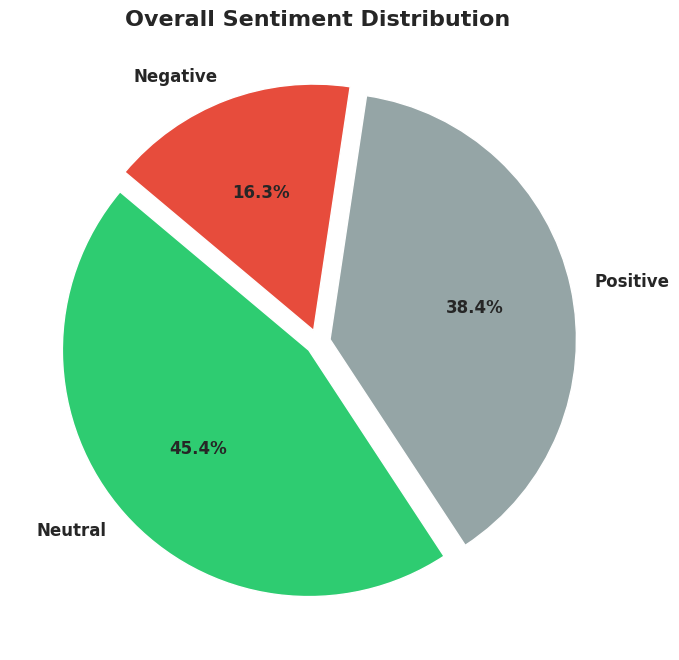

In [ ]:
nlp_pipeline.plot_sentiment_distribution()


=== PHASE 3: WORD CLOUD (POSITIVE) ===


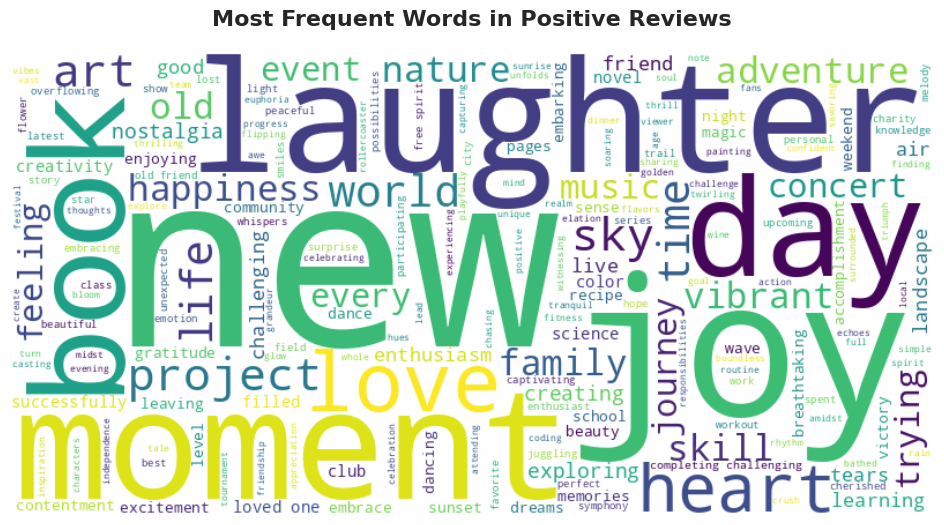

In [ ]:
# Generate word clouds to see what words drive positivity and negativity
nlp_pipeline.generate_wordcloud(sentiment='Positive')


=== PHASE 3: WORD CLOUD (NEGATIVE) ===


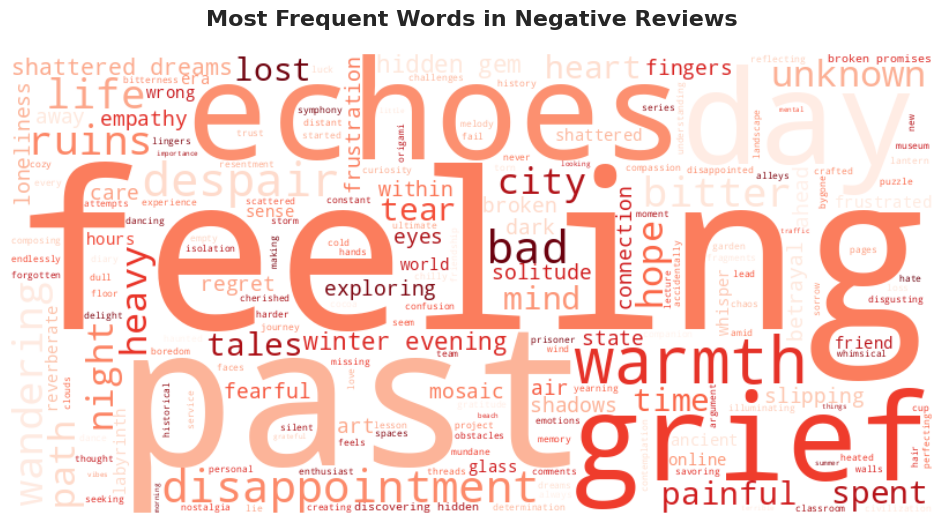

In [ ]:
# Generate word clouds to see what words drive positivity and negativity
nlp_pipeline.generate_wordcloud(sentiment='Negative')